<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/DSP_1_PRATICA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pratica 2 exercício 1


 Gráfico de 500 Hz 



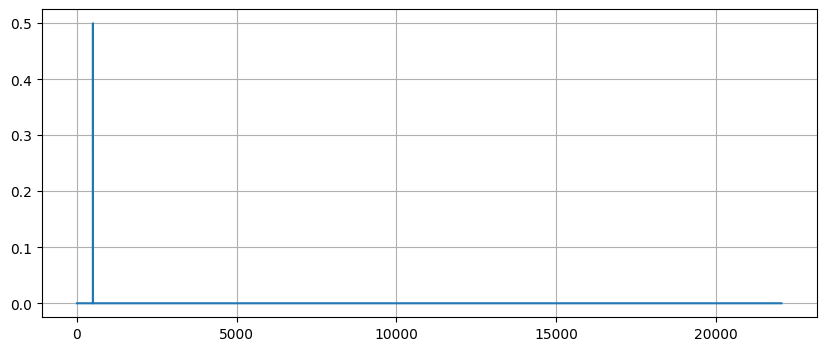


 Gráfico de 1000 Hz 



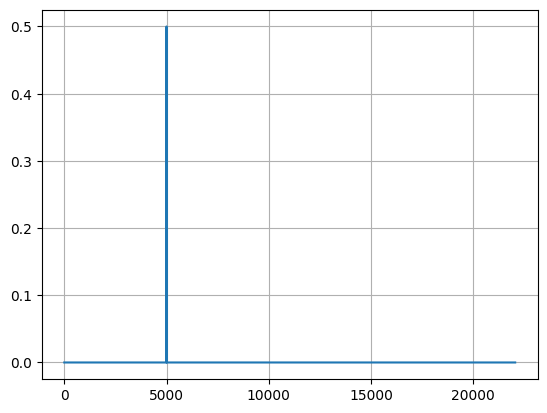


 Gráfico de 10000 Hz 



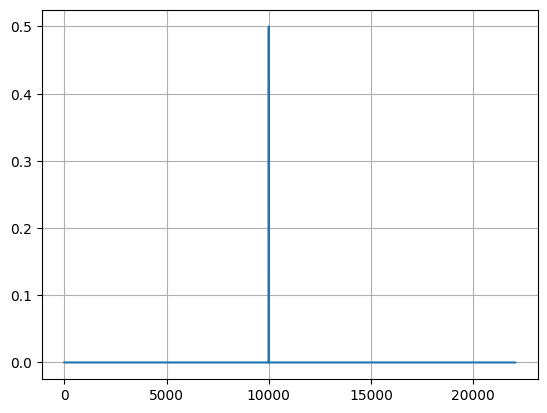


 Gráfico de 50000 Hz 



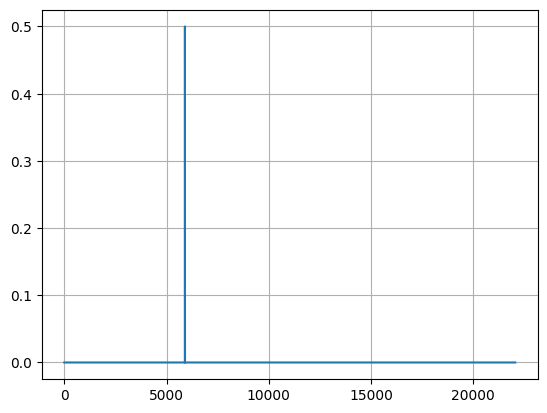

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.signal as signal

#período com frequência de amostragem
t = 1/44100

#frequência_cosseno = 500
#frequência_amostragem = 44.1 kHz
#duração = 1.0

arr = np.arange (0, 1, t, dtype = None)
xA = np.cos(2 * np.pi * 500 * arr)
xB = np.cos(2 * np.pi * 5000 * arr)
xC = np.cos(2 * np.pi * 10000 * arr)
xD = np.cos(2 * np.pi * 50000 * arr)

frequenciasA, espectroA = signal.periodogram(xA, 44100)
frequenciasB, espectroB = signal.periodogram(xB, 44100)
frequenciasC, espectroC = signal.periodogram(xC, 44100)
frequenciasD, espectroD = signal.periodogram(xD, 44100)

plt.figure(figsize = (10,4))

print("\n Gráfico de 500 Hz \n")
plt.plot(frequenciasA, espectroA)

plt.grid(True)
plt.show()

print("\n Gráfico de 1000 Hz \n")
plt.plot(frequenciasB, espectroB)

plt.grid(True)
plt.show()

print("\n Gráfico de 10000 Hz \n")
plt.plot(frequenciasC, espectroC)

plt.grid(True)
plt.show()

print("\n Gráfico de 50000 Hz \n")
plt.plot(frequenciasD, espectroD)

plt.grid(True)
plt.show()

Pratica 2 exercicio 2

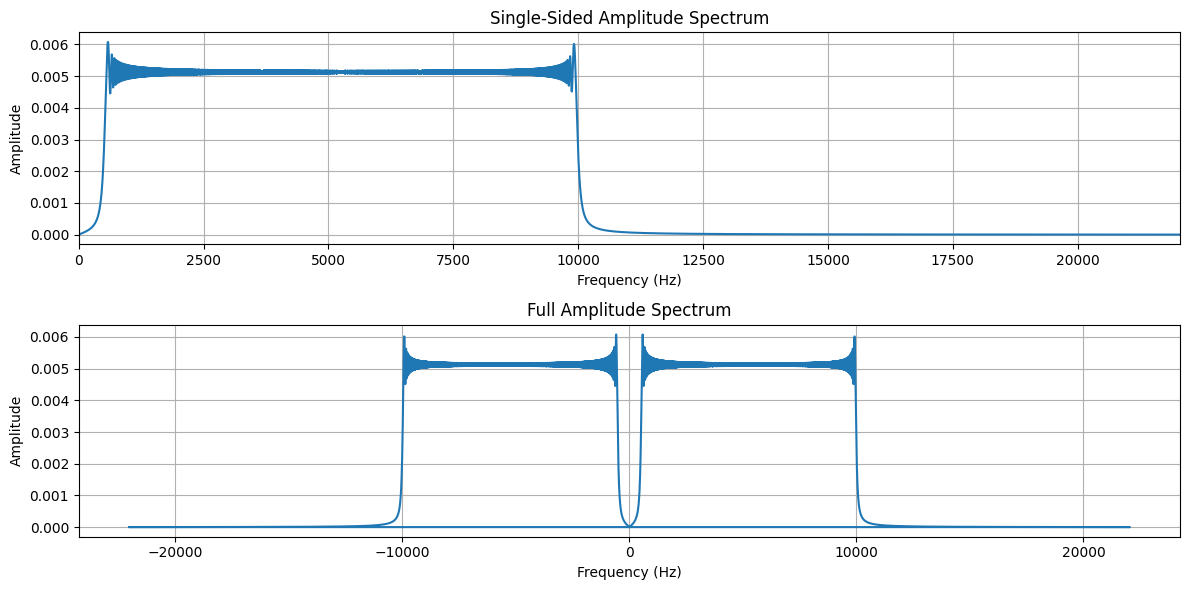

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.fft import fft, fftfreq


fs = 44100                                                           # Frequência de amostragem

# nome do intervalo = np.arange(inicio, fim, passo)
t = np.arange(0, 1, 1/fs)                                            # Intervalo de tempo e amostragem

# nome do sinal = chirp(intervalo de tempo, frequencia inicial, tempo final, frequencia final, método)
sinal = chirp(t, 500, 1, 10000, method = 'linear')

def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(sinal, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(sinal, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

Pratica 2 exercicio 3
No google "como criar uma subamostragem de um sinal em python"

Saving handel.wav to handel (2).wav


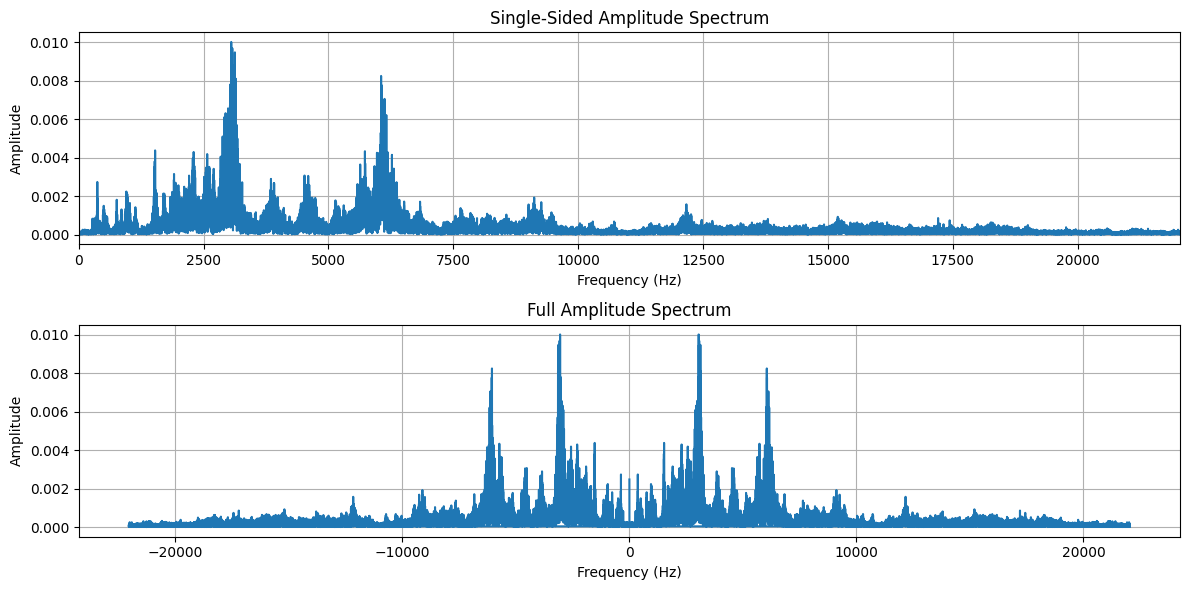

In [ ]:
import numpy as NP
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq

fs = 44100                                                           # Frequência de amostragem

# nome do intervalo = np.arange(inicio, fim, passo)
t = np.arange(0, 1, 1/fs)                                            # Intervalo de tempo e amostragem

#Part (A) formar gráficos com os sons
files.upload()
audioA, file_fsA = sf.read('handel.wav')
duracao_audioA = len(audioA)/file_fsA

#Calculo
def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(audioA, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(audioA, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

Pratica 2 exercicio 4

Saving handel.wav to handel (4).wav


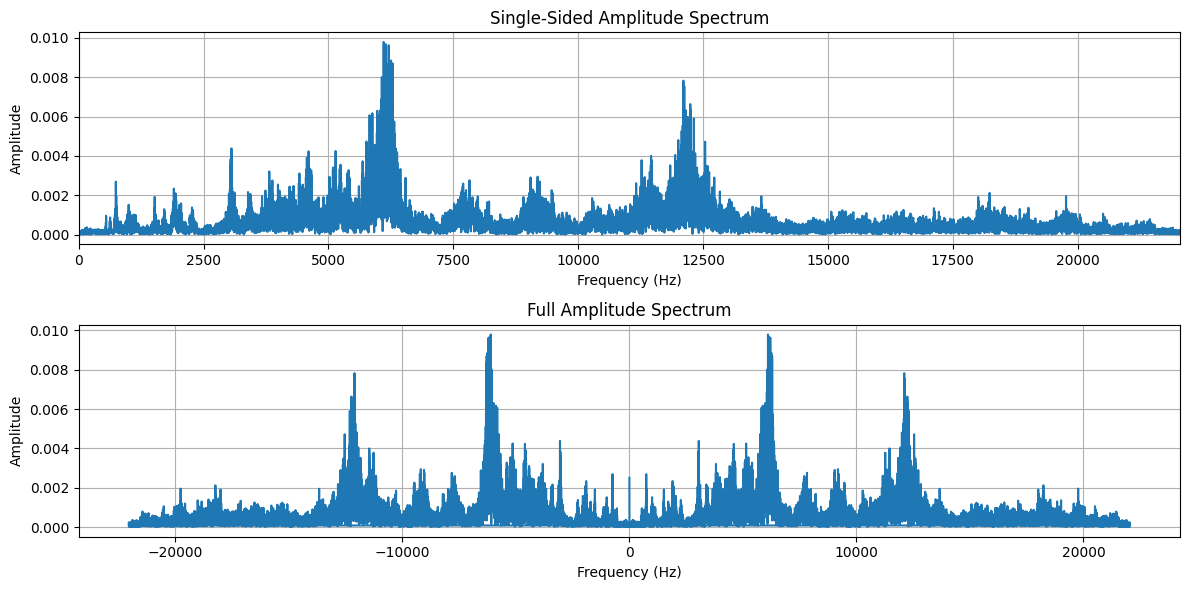

In [ ]:
import numpy as NP
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import decimate
from IPython.display import Audio

fs = 44100                                                           # Frequência de amostragem original

# Fator de subamostragem
fator = 2  # Mantém 1 a cada 4 amostras

# Método 1: Usando slicing (simples, sem filtragem anti-aliasing)

# nome do intervalo = np.arange(inicio, fim, passo)                  # Intervalo de tempo e amostragem

#Part (A) formar gráficos com os sons
files.upload()
audioA, file_fsA = sf.read('handel.wav')
duracao_audioA = len(audioA)/file_fsA

sinal_sub = audioA[::fator]

#Calculo
def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(sinal_sub, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(sinal_sub, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()



display (Audio(sinal_sub, rate = file_fsA))


Pratica 2 Exercício 8 INCOMPLETO


 Gráfico letra A 



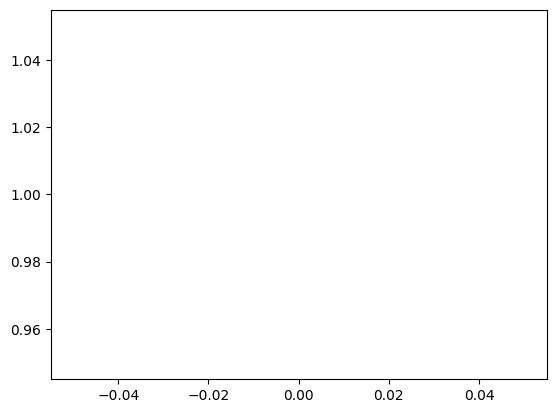


 Gráfico letra B 



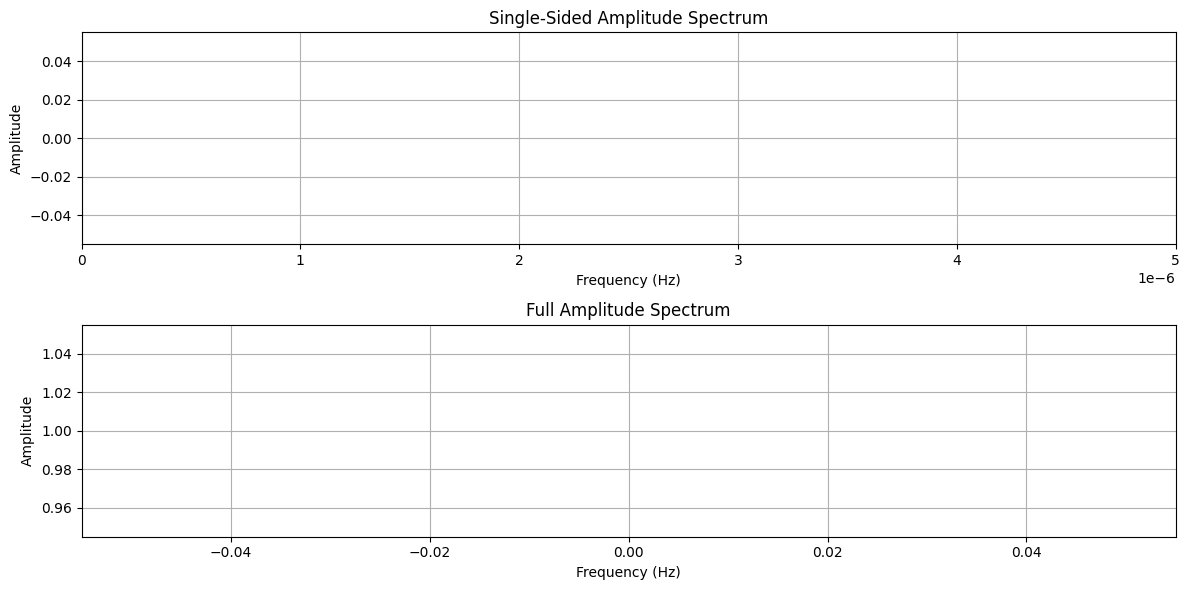


 Gráfico letra C 



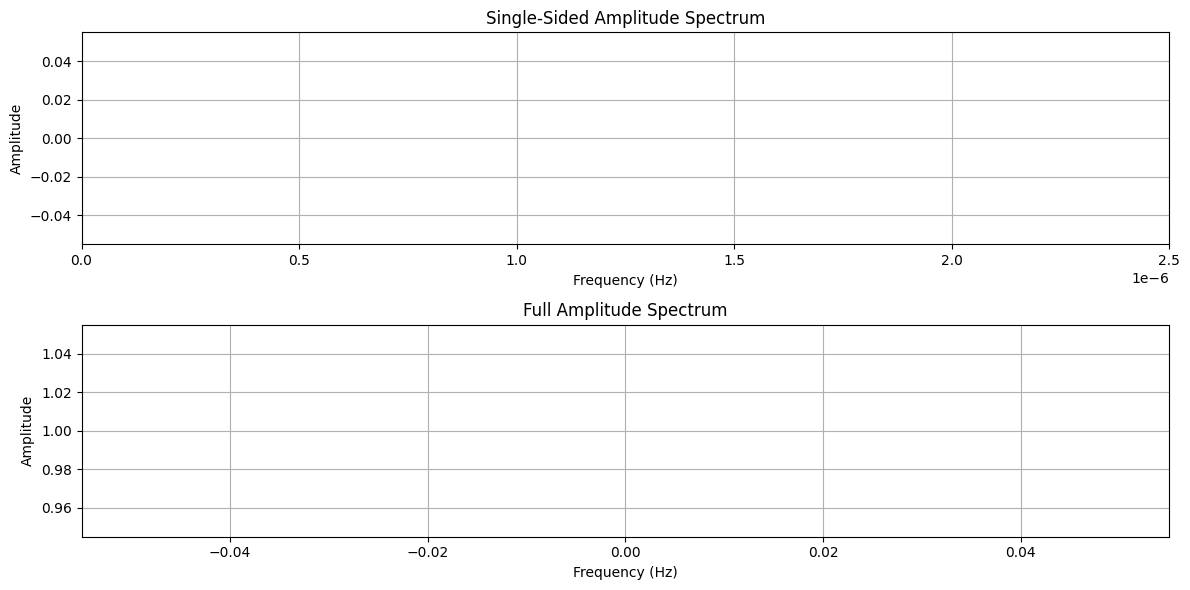

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


/tmp/ipykernel_1153/4256496724.py:131: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  array_de_etapas[I] = np.cos(2000 * np.pi * interval * I) + np.sin (5000 * np.pi * interval * I)


In [42]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

#Frequência de amostragem 10 MHz
fs = 10 * 10 ** -6
T = 1 / fs

#Duração de 10 milisegundos
t = 1 * 10 ** -3

interval = np.arange (0, t, T, dtype=None)

y = np.cos(2000 * np.pi * interval) + np.sin (5000 * np.pi * interval)

print ("\n Gráfico letra A \n")

plt.plot(interval, y)
plt.show()

#LETRA B) Para calcular o specular

def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(y, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(y, fs, single_sided=False)

plt.figure(figsize=(12, 6))

print ("\n Gráfico letra B \n")

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#LETRA C) Com frequência de Nyquist

#Frequência de Nyquist
freq_nyquist = fs/2

def calculate_spectrumB(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumB(y, freq_nyquist, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumB(y, freq_nyquist, single_sided=False)

plt.figure(figsize=(12, 6))

print ("\n Gráfico letra C \n")

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, freq_nyquist / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#LETRA D) Com tempo discreto x[n]

#Intervalo
tempo = 100
array_de_etapas = np.zeros (tempo)
array_de_etapas[0] = np.cos(2000 * np.pi * 0) + np.sin (5000 * np.pi * 0)

#Array para calcular e capturar cada momento dentro de 100 amostras
for I in range (1, tempo):
  array_de_etapas[I] = np.cos(2000 * np.pi * interval * I) + np.sin (5000 * np.pi * interval * I)

print(array_de_etapas)


Pratica 2 Exercício 9

Saving h_banheiro.wav to h_banheiro (1).wav


Saving sinal_taca.wav to sinal_taca (1).wav

 Gráfico 1 do h_banheiro.wav 


 Gráfico 2 do h_banheiro.wav 



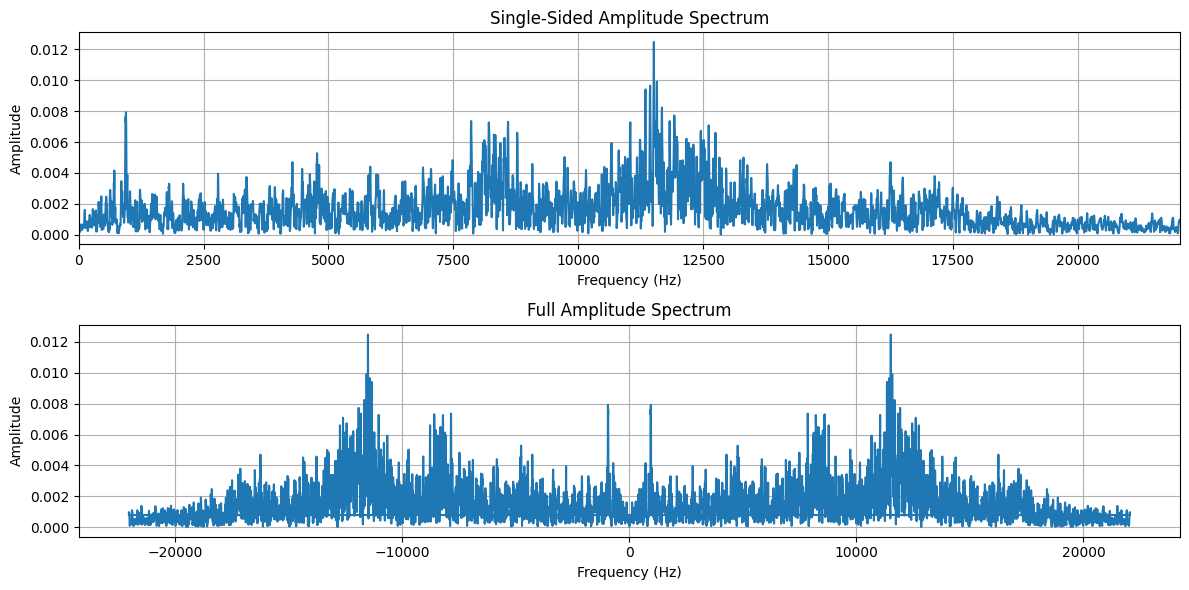


 Gráfico 1 do sinal_taca.wav 


 Gráfico 2 do sinal_taca 



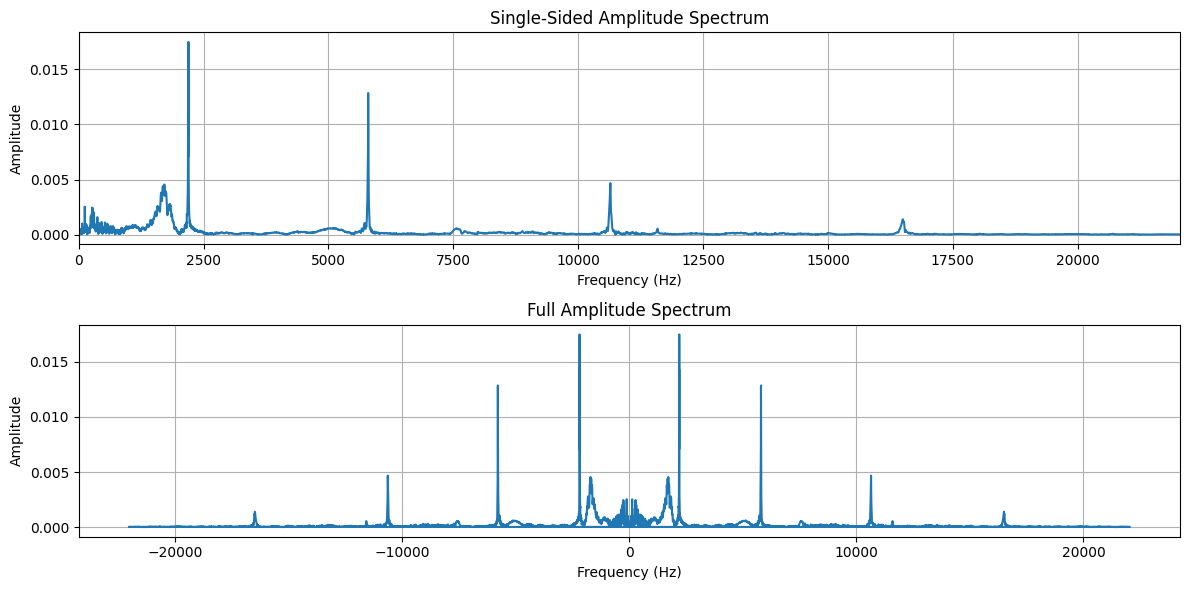

In [44]:
import numpy as NP
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq
from scipy.signal import decimate

fs = 44100
t = 1/44100

files.upload()
audioA, file_FSA = sf.read("h_banheiro.wav")
duracao_audioA = len(audioA)/file_FSA

files.upload()
audioB, file_FSB = sf.read("sinal_taca.wav")
duracao_audioB = len(audioB)/file_FSB

#Parte do h_banheiro.wav
def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(audioA, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(audioA, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ("\n Gráfico 1 do h_banheiro.wav \n")

plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)

print ("\n Gráfico 2 do h_banheiro.wav \n")

plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

#Parte do sinal_taca.wav
def calculate_spectrumA(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrumA(audioB, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrumA(audioB, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ("\n Gráfico 1 do sinal_taca.wav \n")

plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)

print ("\n Gráfico 2 do sinal_taca \n")

plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()